<a href="https://colab.research.google.com/github/Ajinkya718/portfo/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Thu Apr 23 18:34:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.10.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

Computer vision is being used in areas like -
* Manufacturing - Systems scan products on assembly lines to identify defects such as dents or improper alignment, much faster and more accurately than human inspectors.
* Healthcare - Computer vision algorithms analyze x-rays, ct scans and MRIs to detect anomalies, such as tumors or fractures, improving accuracy of the diagnostics.
* Retail/E-commerce - Automated checkout technologies allow for grab and go shopping experiences by identifying items a customer picks up and automatically charging them upon leaving, eliminating checkouts.

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Overfitting in machine learning occurs when the model learns the training data too well and performs badly with testing data. This happens due to having a small training data set or a data containing outliers or noises causing the model to memorize errors instead of learning trends.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

* Increase Training Data: Providing more, diverse training examples helps the model learn underlying patterns rather than memorizing noise.

* Cross-Validation: Using techniques like K-fold cross-validation ensures the model performs well on unseen data subsets, reducing reliance on a single training/validation split.

* Regularization:
L1 Regularization (Lasso): Encourages sparsity by penalizing the absolute size of coefficients, often reducing the influence of irrelevant features.
L2 Regularization (Ridge): Penalizes squared weight values, forcing them to be smaller and reducing model sensitivity to noise.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None,
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 356kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.33MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [4]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

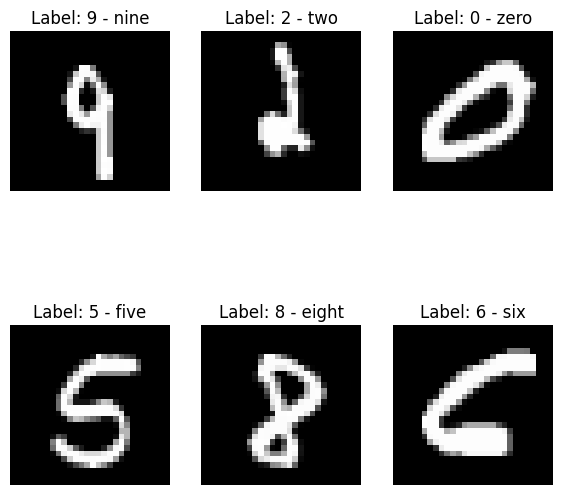

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7,7))
rows, cols = 2, 3
for i in range(1, rows * cols + 1):
    sample_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[sample_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Label: {class_names[label]}")
    plt.axis(False)
plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)
len(train_dataloader), len(test_dataloader)

(1875, 313)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [7]:
import torch
from torch import nn
class MNISTVGG(nn.Module):
    """
    Model architecture copying TinyVGG from CNN Explainer website.
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [8]:
torch.manual_seed(42)
model_0 = MNISTVGG(input_shape=1,
                   hidden_units=10,
                   output_shape=10).to(device)
model_0

MNISTVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [9]:
def total_time_func(start, end, device: torch.device):
    total_time = end - start
    print(f"Total training time on {device}: {total_time:.3f} seconds")
    return total_time

In [10]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [11]:
# Getting loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [12]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
def train_and_evaluate(model, train_dataloader, test_dataloader,
                        loss_fn, optimizer, accuracy_fn,
                        device, num_epochs=5):

    # Move model to target device
    model.to(device)

    results = {"train_loss": [], "test_loss": [], "test_acc": [], "train_time": None}

    start_time = timer()

    for epoch in tqdm(range(num_epochs)):
        print(f"Epoch: {epoch}\n---------")

        ### Training
        train_loss = 0
        for batch, (X, y) in enumerate(train_dataloader):
            X, y = X.to(device), y.to(device)
            model.train()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            train_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if batch % 400 == 0:
                print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

        train_loss /= len(train_dataloader)

        ### Testing
        test_loss, test_acc = 0, 0
        model.eval()
        with torch.inference_mode():
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                test_pred = model(X)
                test_loss += loss_fn(test_pred, y).item()
                test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
            test_loss /= len(test_dataloader)
            test_acc /= len(test_dataloader)

        print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.4f}%")
        results["train_loss"].append(train_loss)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    end_time = timer()
    results["train_time"] = total_time_func(start=start_time, end=end_time, device=str(device))

    return results

In [13]:
torch.manual_seed(42)
train_and_evaluate(model_0, train_dataloader, test_dataloader,
                   loss_fn, optimizer, accuracy_fn,
                   device = "cpu", num_epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.32017 | Test loss: 0.07544 | Test acc: 97.7236%
Epoch: 1
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.08204 | Test loss: 0.06162 | Test acc: 97.9233%
Epoch: 2
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.06394 | Test loss: 0.05525 | Test acc: 98.1030%
Epoch: 3
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.05469 | Test loss: 0.04741 | Test acc: 98.3826%
Epoch: 4
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/6

{'train_loss': [0.3201699062969225,
  0.08203597874703507,
  0.0639368259685114,
  0.054689562294946516,
  0.0482506607286244],
 'test_loss': [0.07544001885734428,
  0.06161613829066447,
  0.05524750022669206,
  0.047407554672973695,
  0.0463732118080134],
 'test_acc': [97.72364217252397,
  97.92332268370608,
  98.10303514376997,
  98.38258785942492,
  98.3526357827476],
 'train_time': 208.981358068}

In [14]:
# Good practice to reinitialize your optimizer as the parameters could be tied to the device run and may carry stale gradient history
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [15]:
torch.manual_seed(42)
train_and_evaluate(model_0, train_dataloader, test_dataloader,
                   loss_fn, optimizer, accuracy_fn,
                   device, num_epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.04431 | Test loss: 0.04618 | Test acc: 98.3926%
Epoch: 1
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.03998 | Test loss: 0.05438 | Test acc: 98.2628%
Epoch: 2
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.03722 | Test loss: 0.04374 | Test acc: 98.5823%
Epoch: 3
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.03549 | Test loss: 0.04051 | Test acc: 98.6022%
Epoch: 4
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/6

{'train_loss': [0.044311909652656564,
  0.03997648673115861,
  0.03721973678633803,
  0.03548721148635765,
  0.032841116346787505],
 'test_loss': [0.04617742335428662,
  0.05438316295736751,
  0.0437415324797632,
  0.04050796415683584,
  0.03998234206967271],
 'test_acc': [98.39257188498402,
  98.26277955271566,
  98.58226837060703,
  98.60223642172524,
  98.57228434504792],
 'train_time': 67.470703749}

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?